<a href="https://colab.research.google.com/github/RanaMagdyisaac/Churn-Modelling-PyTorch/blob/main/FCNN_Churn_Modelling_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

In [2]:
df = pd.read_csv('/content/Churn_Modelling.csv')
display(df.head(20))

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:

print("Data Info:")
df.info()

print("\n" + "="*50 + "\n")

print("Data Summary:")
summary = df.describe()
display(summary)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Data Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


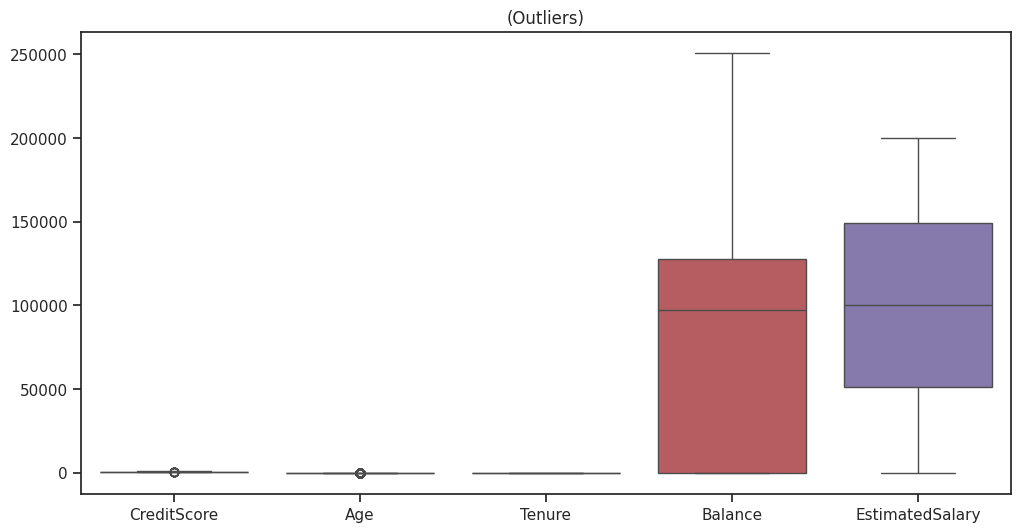

In [5]:

sns.set(style="ticks")

continuous_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_features])
plt.title("(Outliers)")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

#  Drop columns that do not affect the customer's decision
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

#  Convert categorical variables (Geography, Gender) to numerical (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, drop_first=True)

#  Separate features (X) and target variable (y)
X = df_clean.drop('Exited', axis=1).values
y = df_clean['Exited'].values

#  Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  Convert data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("Data shapes after preprocessing:")
print("X_train shape:", X_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)

Data shapes after preprocessing:
X_train shape: torch.Size([8000, 11])
y_train shape: torch.Size([8000, 1])


In [7]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the FCNN Model
class ChurnClassifier(nn.Module):
    def __init__(self, input_dim):
        super(ChurnClassifier, self).__init__()
        # Hidden layer 1
        self.layer1 = nn.Linear(input_dim, 16)
        self.relu1 = nn.ReLU()

        # Hidden layer 2
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        # Output layer
        self.output_layer = nn.Linear(8, 1)
        # Sigmoid is deliberately removed here; it will be handled by the loss function

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu1(out)
        out = self.layer2(out)
        out = self.relu2(out)
        out = self.output_layer(out)
        return out

# 2. Instantiate the model
input_size = X_train_tensor.shape[1]
model = ChurnClassifier(input_size)
print(model)

# 3. Calculate weights to fix class imbalance
num_negatives = (y_train_tensor == 0).sum()
num_positives = (y_train_tensor == 1).sum()
pos_weight = num_negatives / num_positives
print(f"\nPositive Weight applied to Loss: {pos_weight.item():.2f}")

# 4. Define Loss Function and Optimizer

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

ChurnClassifier(
  (layer1): Linear(in_features=11, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)

Positive Weight applied to Loss: 3.87


In [8]:

epochs = 200

print("Start Training...")

for epoch in range(epochs):
    # Set model to training mode
    model.train()

    #  Forward pass
    y_pred_logits = model(X_train_tensor)

    loss = criterion(y_pred_logits, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("Training Completed!")

Start Training...
Epoch [20/200], Loss: 1.0791
Epoch [40/200], Loss: 1.0394
Epoch [60/200], Loss: 0.9938
Epoch [80/200], Loss: 0.9510
Epoch [100/200], Loss: 0.9163
Epoch [120/200], Loss: 0.8876
Epoch [140/200], Loss: 0.8622
Epoch [160/200], Loss: 0.8389
Epoch [180/200], Loss: 0.8176
Epoch [200/200], Loss: 0.7985
Training Completed!


Accuracy : 0.753
Precision: 0.42857142857142855
Recall   : 0.7709923664122137
F1-score : 0.5509090909090909
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      1607
         1.0       0.43      0.77      0.55       393

    accuracy                           0.75      2000
   macro avg       0.68      0.76      0.69      2000
weighted avg       0.83      0.75      0.77      2000



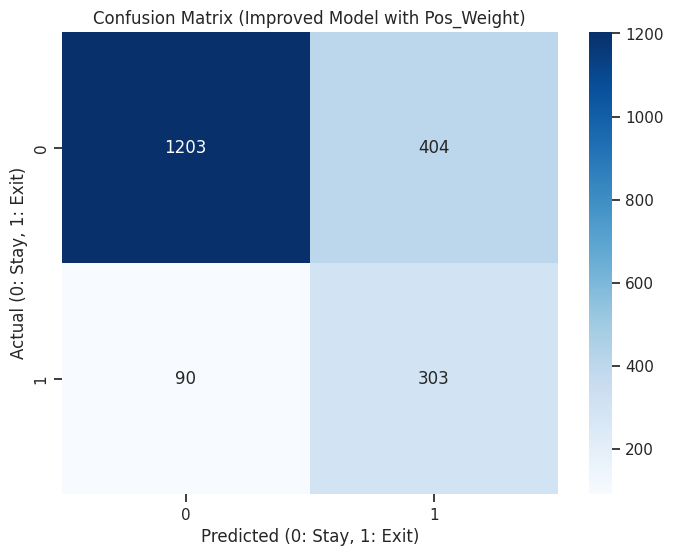

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


model.eval()

with torch.no_grad():

    y_test_logits = model(X_test_tensor)

    #  Apply Sigmoid to convert logits to probabilities
    y_pred_prob = torch.sigmoid(y_test_logits).numpy()

    #  Convert probabilities to binary classes (0 or 1)
    y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

    # Convert actual test labels to numpy
    y_test_actual = y_test_tensor.numpy().ravel()

# 5. Print Metrics
print("Accuracy :", accuracy_score(y_test_actual, y_pred))
print("Precision:", precision_score(y_test_actual, y_pred))
print("Recall   :", recall_score(y_test_actual, y_pred))
print("F1-score :", f1_score(y_test_actual, y_pred))
print("-" * 50)

#  Classification Report
print("Classification Report:")
print(classification_report(y_test_actual, y_pred))

cm = confusion_matrix(y_test_actual, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted (0: Stay, 1: Exit)")
plt.ylabel("Actual (0: Stay, 1: Exit)")
plt.title("Confusion Matrix (Improved Model with Pos_Weight)")
plt.show()

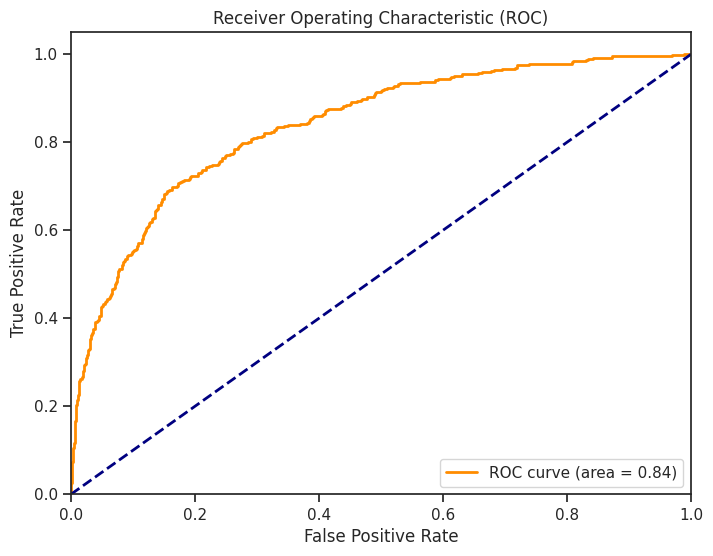

In [10]:
from sklearn.metrics import roc_curve, auc

y_pred_prob_tensor = torch.sigmoid(y_test_logits)
y_pred_prob_numpy = y_pred_prob_tensor.numpy()

fpr, tpr, thresholds = roc_curve(y_test_actual, y_pred_prob_numpy)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()